<a href="https://colab.research.google.com/github/varakalicheva-hub/compling/blob/main/%D0%9A%D0%B0%D0%BB%D0%B8%D1%87%D0%B5%D0%B2%D0%B0__%22convnet_hw_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Домашнее задание: бинарная классификация отзывов с помощью CNN

Применить CNN для анализа тональности текста (положительный/отрицательный отзыв)

Заполните пропущенный код (`### ВАШ КОД ЗДЕСЬ ###`). **Не меняйте структуру ячеек!** Все ответы и графики должны генерироваться автоматически

**Критерии проверки (максимум 10 баллов):**
*   **2 балла** — корректная загрузка и предобработка данных.
*   **3 балла** — корректно собранная модель по спецификации.
*   **2 балла** — успешное обучение модели (вывод истории обучения).
*   **3 балла** — оценка на тесте и выводы (accuracy > 0.85 даёт +1 балл).

---

## БЛОК 1: Загрузка данных

Тренировочные данные: 25000 samples
Тестовые данные: 25000 samples


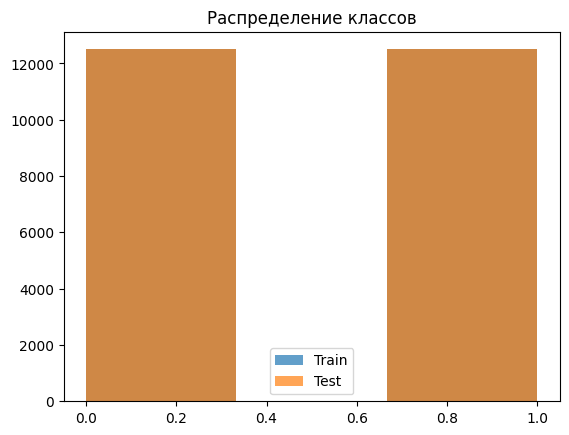

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
import tensorflow_datasets as tfds

# 1. Загрузите датасет IMDB Reviews (бинарная классификация)
(train_ds, test_ds) = tfds.load(
    'imdb_reviews',
    split=['train', 'test'],
    as_supervised=True
)

# Преобразуем tf.data.Dataset в numpy
x_train, y_train = zip(*tfds.as_numpy(train_ds))
x_test, y_test = zip(*tfds.as_numpy(test_ds))

x_train = np.array(x_train, dtype=object)
y_train = np.array(y_train)

x_test = np.array(x_test, dtype=object)
y_test = np.array(y_test)


print(f"Тренировочные данные: {len(x_train)} samples")
print(f"Тестовые данные: {len(x_test)} samples")

# 2. Визуализируйте распределение классов
plt.hist(y_train, bins=3, alpha=0.7, label='Train')
plt.hist(y_test, bins=3, alpha=0.7, label='Test')
plt.legend()
plt.title('Распределение классов')
plt.show()

## БЛОК 2: Предобработка текста

In [10]:
# 3. Создайте текстовый векторзатор (TextVectorization)
# Ограничьте словарь 10_000 самых частых слов, максимальную длину последовательности — 200 слов
### ВАШ КОД ЗДЕСЬ ###
vectorizer = keras.layers.TextVectorization(
    max_tokens=10_000,
    output_sequence_length=200
)
# 4. Адаптируйте векторзатор на тренировочных текстах
### ВАШ КОД ЗДЕСЬ ###
vectorizer.adapt(x_train)

# 5. Примените векторзацию к данным
x_train_vec = vectorizer(x_train).numpy()
x_test_vec = vectorizer(x_test).numpy()

print(f"Размерность после векторизации: {x_train_vec.shape}")

Размерность после векторизации: (25000, 200)


## БЛОК 3: Построение модели

In [17]:
# 6. Постройте модель CNN для текста СТРОГО ПО СПЕЦИФИКАЦИИ:
#    - Вход: векторная последовательность (200,)
#    - Embedding: размерность 128, входной словарь 10_000
#    - Conv1D: 64 фильтра, размер ядра 5, активация 'relu'
#    - GlobalMaxPooling1D
#    - Dense: 32 нейрона, 'relu'
#    - Dense: 1 нейрон, 'sigmoid' (бинарная классификация)
### ВАШ КОД ЗДЕСЬ ###
model = keras.Sequential([keras.layers.Input(shape=(200, )),
    keras.layers.Embedding(input_dim=10000, output_dim=128),
    keras.layers.Conv1D(filters=64, kernel_size=5, activation='relu'),
    keras.layers.GlobalMaxPooling1D(),
    keras.layers.Dense(32, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')])

model.summary()

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_6 (Embedding)         │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_6 (Conv1D)               │ (None, 196, 64)        │        41,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d_6          │ (None, 64)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,323,137 (5.05 MB)

 Trainable params: 1,323,137 (5.05 MB)

 Non-trainable params: 0 (0.00 B)

## БЛОК 4: Обучение

Epoch 1/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 63ms/step - accuracy: 0.6894 - loss: 0.5571 - precision: 0.6781 - recall: 0.7291 - val_accuracy: 0.8626 - val_loss: 0.3188 - val_precision: 0.8791 - val_recall: 0.8447
Epoch 2/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 63ms/step - accuracy: 0.9294 - loss: 0.1961 - precision: 0.9270 - recall: 0.9323 - val_accuracy: 0.8694 - val_loss: 0.3126 - val_precision: 0.8839 - val_recall: 0.8542
Epoch 3/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 64ms/step - accuracy: 0.9904 - loss: 0.0489 - precision: 0.9905 - recall: 0.9902 - val_accuracy: 0.8686 - val_loss: 0.3709 - val_precision: 0.8669 - val_recall: 0.8748
Epoch 4/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 0.9996 - loss: 0.0075 - precision: 0.9995 - recall: 0.9996 - val_accuracy: 0.8750 - val_loss: 0.4274 - val_precision: 0.8700 - val_recall: 0.8854
Epoch 5/5
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 62ms/step - accuracy: 1.0000 - loss: 0.0012 - precision: 1.0000 - recall: 1.0000 - val_accuracy: 0.8734 - val_los

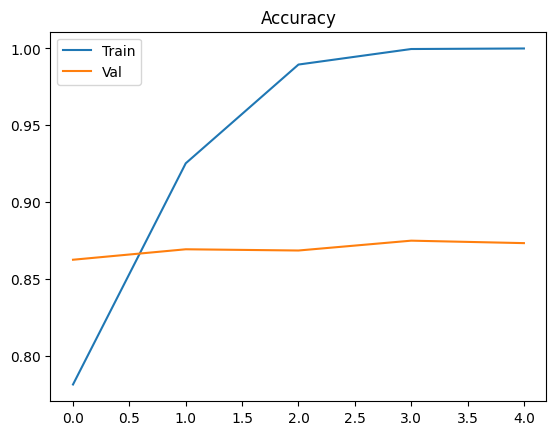

In [19]:
# 7. Скомпилируйте модель с оптимизатором 'adam', функцией потерь 'binary_crossentropy',
#    метриками ['accuracy', 'Precision', 'Recall']
### ВАШ КОД ЗДЕСЬ ###
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        keras.metrics.Precision(),
        keras.metrics.Recall()
    ]
)


# 8. Обучите модель на 5 эпох с validation_split=0.2, batch_size=32
### ВАШ КОД ЗДЕСЬ ###
history = model.fit(
    x_train_vec,
    y_train,
    epochs=5,
    batch_size=32,
    validation_split=0.2
)

# 9. Постройте график точности (accuracy) на обучении и валидации
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()
plt.show()

## БЛОК 5: Оценка

In [21]:
# 10. Оцените модель на тестовых данных
### ВАШ КОД ЗДЕСЬ ###
test_loss, test_acc, test_prec, test_rec = model.evaluate(
    x_test_vec,
    y_test
)

print(f"Тестовая accuracy: {test_acc:.4f}")
print(f"Тестовая precision: {test_prec:.4f}")
print(f"Тестовая recall: {test_rec:.4f}")

# 11. Сделайте предсказания на первых 10 тестовых отзывах
#     и выведите: текст отзыва, истинный класс, предсказанный класс, вероятность
for i in range(10):
    text = x_test[i]
    true_label = "POS" if y_test[i] == 1 else "NEG"
    ### ВАШ КОД ЗДЕСЬ ###
    # 11. Предсказания на первых 10 тестовых отзывах
for i in range(10):
    text = x_test[i]
    true_label = "POS" if y_test[i] == 1 else "NEG"

    pred_prob = model.predict(x_test_vec[i:i+1])
    pred_label = "POS" if pred_prob > 0.5 else "NEG"

    print(f"{text[:50]}... | True: {true_label} | Pred: {pred_label} ({pred_prob[0][0]:.2f})")

782/782 ━━━━━━━━━━━━━━━━━━━━ 11s 14ms/step - accuracy: 0.8663 - loss: 0.5003 - precision: 0.8658 - recall: 0.8655
Тестовая accuracy: 0.8660
Тестовая precision: 0.8678
Тестовая recall: 0.8637
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 119ms/step
b'There are films that make careers. For George Rome'... | True: POS | Pred: POS (0.99)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
b'A blackly comic tale of a down-trodden priest, Naz'... | True: POS | Pred: POS (0.99)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
b'Scary Movie 1-4, Epic Movie, Date Movie, Meet the '... | True: NEG | Pred: NEG (0.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
b'Poor Shirley MacLaine tries hard to lend some grav'... | True: NEG | Pred: NEG (0.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
b'As a former Erasmus student I enjoyed this film ve'... | True: POS | Pred: POS (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
b'My God, Ryan Gosling has made a lot of deep charac'... | True: POS | Pred: POS (1.00)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
b'This film ju

## БЛОК 6: Выводы

**Ответьте на вопросы в этой ячейке (текстом):**

1.  Какая итоговая точность (accuracy) на тесте?
2.  Что показывает разница между точностью на обучении и валидации? Есть ли переобучение?
3.  Какой из 10 показанных отзывов был классифицирован неверно? Почему, на ваш взгляд?

**Мои ответы:**
1.  accuracy: 0.8663
2.  Train accuracy — насколько хорошо модель угадывает ответ на тех данных, которые она уже видела. Validation accuracy — насколько хорошо она работает на новых данных, которые она еще не видела. Переобучение начинается после 2-ой эпохи (до этого val_loss падает), так как метрика начинает расти.
3.  Есть два предположения, почему последний отзыв был неправильно определен: 1) модель переобучилась и 2) лексическая сложность, возникающая из-за столкновения слова "great", которое подразумевает под собой положительную оценку и слова "stumble", которое интерпретироваться как неожиданное или нежелательное, что сбивает тон.